<a href="https://colab.research.google.com/github/wowmfoqlt5/health-checkup-analysis/blob/feature%2Fdata-cleaning/notebook/%ED%86%B5%EA%B3%84%EA%B8%B0%EC%B4%88_%EB%B0%8F_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%8B%9C%EA%B0%81%ED%99%94_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

# 한글 폰트 설정 (Colab)
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic'); plt.rc('axes', unicode_minus=False)
sns.set_theme(style='whitegrid', palette='colorblind', font='NanumGothic')

# --- Colab에 엑셀 업로드 후 읽기 ---
from google.colab import files
files.upload()                      # 건강검진_실습데이터.xlsx 선택

df = pd.read_excel('건강검진_실습데이터.xlsx')
df.head()

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


Saving 건강검진_실습데이터.xlsx to 건강검진_실습데이터.xlsx


,id,age,sex,region,smoking,exercise_freq,bmi,waist,sbp,glucose,tg,hdl,crp,metabolic_syndrome
0,1,66,남,충청,흡연,0,25.9,118.9,150,116,46,34.0,2.65,1
1,2,41,여,호남,비흡연,2,26.8,108.3,129,109,70,60.0,0.48,0
2,3,46,남,영남,흡연,0,27.6,112.6,144,113,79,48.0,0.66,0
3,4,35,남,영남,비흡연,0,26.2,108.1,134,109,46,50.0,1.44,0
4,5,60,여,호남,흡연,3,22.3,99.5,149,125,98,55.0,0.30,1


In [ ]:
print(df.shape)        # (400, 14)  — 환자 400명, 변수 14개
df.info()              # 각 변수 타입과 결측(Non-Null) 확인
df.columns.tolist()    # 변수 이름 목록

(400, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  400 non-null    int64  
 1   age                 400 non-null    int64  
 2   sex                 400 non-null    object 
 3   region              400 non-null    object 
 4   smoking             400 non-null    object 
 5   exercise_freq       400 non-null    int64  
 6   bmi                 400 non-null    float64
 7   waist               400 non-null    float64
 8   sbp                 400 non-null    int64  
 9   glucose             400 non-null    int64  
 10  tg                  400 non-null    int64  
 11  hdl                 394 non-null    float64
 12  crp                 388 non-null    float64
 13  metabolic_syndrome  400 non-null    int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 43.9+ KB


['id',
 'age',
 'sex',
 'region',
 'smoking',
 'exercise_freq',
 'bmi',
 'waist',
 'sbp',
 'glucose',
 'tg',
 'hdl',
 'crp',
 'metabolic_syndrome']

In [ ]:
crp = df['crp'].dropna()           # 결측 제외
print(f"평균={crp.mean():.2f}  중앙값={crp.median():.2f}")

# --- 강건성 체험: 측정 오류로 CRP=100 하나가 섞였다고 가정 ---
contaminated = pd.concat([crp, pd.Series([100.0])])
print(f"[오염 전→후] 평균  : {crp.mean():.2f} → {contaminated.mean():.2f}")    # 대표값 무너짐
print(f"[오염 전→후] 중앙값: {crp.median():.2f} → {contaminated.median():.2f}") # 거의 그대로

# 절사평균(양 끝 10% 제거): 평균과 중앙값의 절충
print("10% 절사평균:", round(stats.trim_mean(crp, 0.1), 2))



평균=0.59  중앙값=0.48
[오염 전→후] 평균  : 0.59 → 0.84
[오염 전→후] 중앙값: 0.48 → 0.48
10% 절사평균: 0.52



피어슨 왜도계수 = (0.59 - 0.48) / 0.41 = 0.26


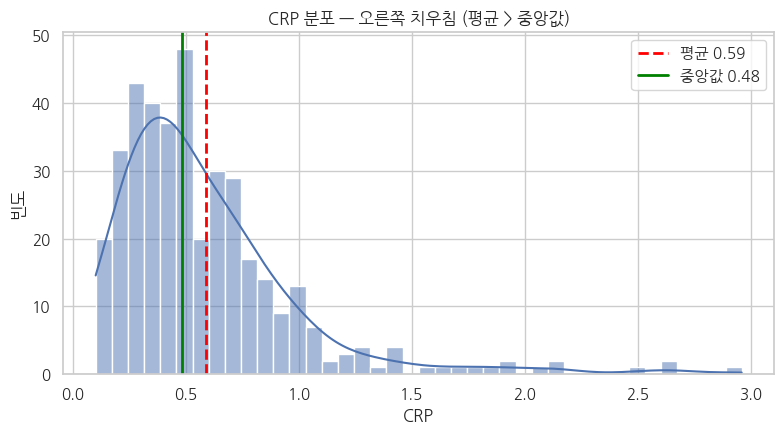

In [ ]:
# --- 피어슨 왜도계수: (평균 - 중앙값) / 표준편차 ---
# 양수면 오른쪽 치우침, 0에 가까우면 대칭
pearson_skew = (crp.mean() - crp.median()) / crp.std()
print(f"\n피어슨 왜도계수 = ({crp.mean():.2f} - {crp.median():.2f}) / {crp.std():.2f} "
      f"= {pearson_skew:.2f}")

# --- 실제 분포 시각화: 평균 vs 중앙값 위치 함께 표시 ---
plt.figure(figsize=(8, 4.5))
sns.histplot(crp, bins=40, kde=True, color='#4C72B0')
plt.axvline(crp.mean(),   color='red',   linestyle='--', linewidth=2,
            label=f'평균 {crp.mean():.2f}')
plt.axvline(crp.median(), color='green', linestyle='-',  linewidth=2,
            label=f'중앙값 {crp.median():.2f}')
plt.title('CRP 분포 — 오른쪽 치우침 (평균 > 중앙값)')
plt.xlabel('CRP'); plt.ylabel('빈도')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
from scipy import stats

# 평균=100, 평균차=+5로 고정하고 산포만 바꿔본다
np.random.seed(0)
n = 30
mean_A, mean_B = 100, 105          # 두 집단의 평균차는 항상 +5

print("평균차는 +5로 동일. 산포(SD)만 바꿔가며 t·p가 어떻게 변하는지 관찰\n")
print(f"{'SD':>4} | {'평균차':>5} | {'SE':>5} | {'t값':>6} | {'p값':>7} | 판정")
print("-" * 50)
for sd in [1, 5, 15]:              # 산포: 작음 → 큼
    a = np.random.normal(mean_A, sd, n)
    b = np.random.normal(mean_B, sd, n)
    t, p = stats.ttest_ind(a, b)
    se = np.sqrt(a.var(ddof=1)/n + b.var(ddof=1)/n)
    verdict = "유의함" if p < 0.05 else "유의하지 않음"
    print(f"{sd:>4} | {b.mean()-a.mean():>5.1f} | {se:>5.2f} | "
          f"{t:>6.2f} | {p:>7.4f} | {verdict}")


평균차는 +5로 동일. 산포(SD)만 바꿔가며 t·p가 어떻게 변하는지 관찰

  SD |   평균차 |    SE |     t값 |      p값 | 판정
--------------------------------------------------
   1 |   4.3 |  0.26 | -16.34 |  0.0000 | 유의함
   5 |   8.2 |  1.28 |  -6.42 |  0.0000 | 유의함
  15 |   2.5 |  3.61 |  -0.70 |  0.4839 | 유의하지 않음


count    388.000000
mean       0.586443
std        0.412610
min        0.100000
25%        0.320000
50%        0.480000
75%        0.730000
max        2.960000
Name: crp, dtype: float64
IQR=0.41  경계=(-0.29, 1.34)  이상치 후보=19명
0.05    0.17
0.25    0.32
0.50    0.48
0.75    0.73
0.95    1.27
Name: crp, dtype: float64


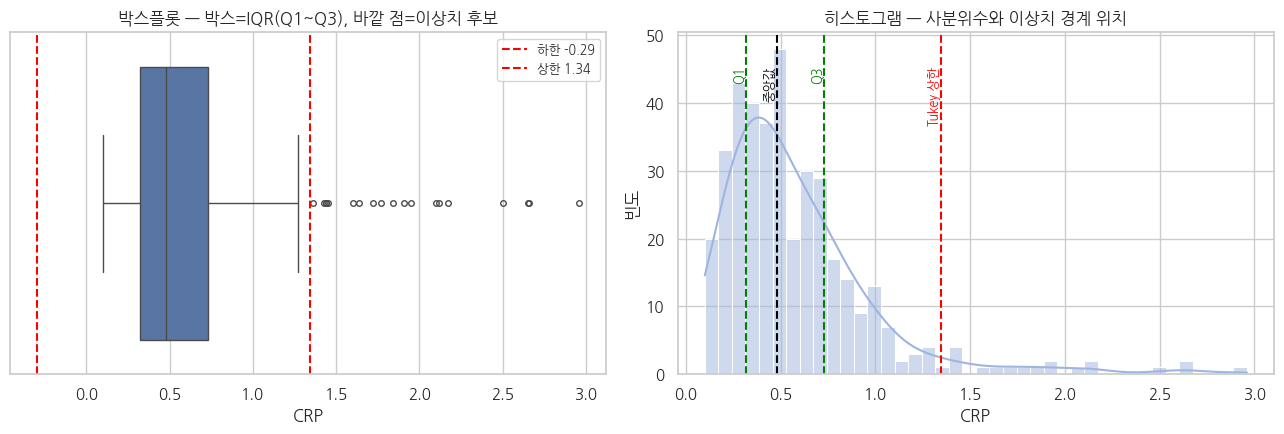

In [ ]:
print(df['crp'].describe())                 # count=388 → 결측 12개 반영 확인

Q1, Q3 = df['crp'].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR       # Tukey 경계
outliers = df[(df['crp'] < low) | (df['crp'] > high)]
print(f"IQR={IQR:.2f}  경계=({low:.2f}, {high:.2f})  이상치 후보={len(outliers)}명")

# 여러 분위수 한 번에
print(df['crp'].quantile([.05, .25, .5, .75, .95]).round(2))

# --- 시각화: 박스플롯 + Tukey 경계, 그리고 히스토그램에 사분위 표시 ---
crp = df['crp'].dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (왼쪽) 박스플롯 — 박스=IQR, 수염 끝≈경계, 점=이상치 후보
sns.boxplot(x=crp, ax=ax[0], color='#4C72B0', fliersize=4)
ax[0].axvline(low,  color='red', linestyle='--', linewidth=1.5, label=f'하한 {low:.2f}')
ax[0].axvline(high, color='red', linestyle='--', linewidth=1.5, label=f'상한 {high:.2f}')
ax[0].set_title('박스플롯 — 박스=IQR(Q1~Q3), 바깥 점=이상치 후보')
ax[0].set_xlabel('CRP'); ax[0].legend(loc='upper right', fontsize=9)

# (오른쪽) 히스토그램에 Q1·중앙·Q3·상한 위치 표시
sns.histplot(crp, bins=40, kde=True, color='#9FB4DF', ax=ax[1])
for val, txt, c in [(Q1, 'Q1', 'green'), (crp.median(), '중앙값', 'black'),
                    (Q3, 'Q3', 'green'), (high, 'Tukey 상한', 'red')]:
    ax[1].axvline(val, color=c, linestyle='--', linewidth=1.5)
    ax[1].text(val, ax[1].get_ylim()[1]*0.9, txt, rotation=90,
               va='top', ha='right', fontsize=9, color=c)
ax[1].set_title('히스토그램 — 사분위수와 이상치 경계 위치')
ax[1].set_xlabel('CRP'); ax[1].set_ylabel('빈도')

plt.tight_layout(); plt.show()

표본분산(n-1): 147.71
SD=12.15  CV=8.7%
|Z|>3 인원: 0
age      평균=  52.3  SD= 12.4  CV= 23.7%
sbp      평균= 139.8  SD= 12.2  CV=  8.7%
glucose  평균= 113.9  SD=  7.5  CV=  6.6%
crp      평균=   0.6  SD=  0.4  CV= 70.4%


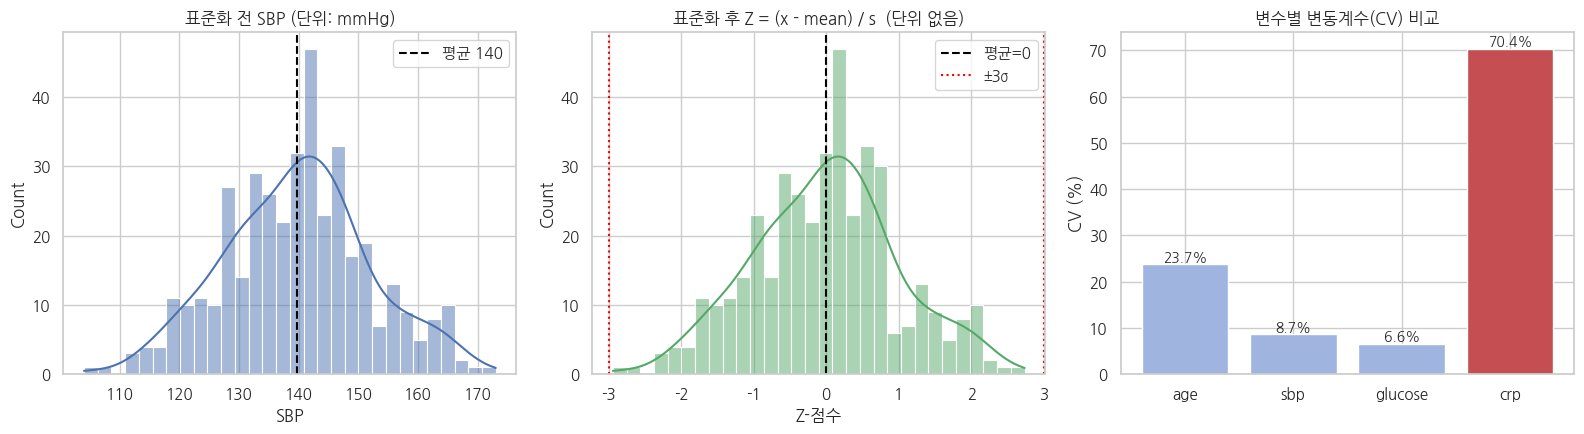

In [ ]:
x = df['sbp']
print("표본분산(n-1):", round(x.var(ddof=1), 2))    # pandas 기본
print(f"SD={x.std():.2f}  CV={x.std()/x.mean()*100:.1f}%")

# 표준화 후 |Z|>3 이상치
z = (x - x.mean()) / x.std()
print("|Z|>3 인원:", (z.abs() > 3).sum())

# 단위가 다른 변수의 변동 비교 → CV
cv_table = {}
for col in ['age', 'sbp', 'glucose', 'crp']:
    s = df[col].dropna()
    cv = s.std() / s.mean() * 100
    cv_table[col] = cv
    print(f"{col:8s} 평균={s.mean():6.1f}  SD={s.std():5.1f}  CV={cv:5.1f}%")

# --- 시각화 ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) 표준화 전: 원래 단위의 SBP 분포 (x축 = mmHg)
sns.histplot(x, bins=30, kde=True, color='#4C72B0', ax=ax[0])
ax[0].axvline(x.mean(), color='black', ls='--', label=f'평균 {x.mean():.0f}')
ax[0].set_title('표준화 전 SBP (단위: mmHg)'); ax[0].set_xlabel('SBP'); ax[0].legend()

# (2) 표준화 후: Z 분포 (x축 = 표준편차 단위), ±3 경계 표시
sns.histplot(z, bins=30, kde=True, color='#55A868', ax=ax[1])
ax[1].axvline(0, color='black', ls='--', label='평균=0')
ax[1].axvline(3,  color='red', ls=':')
ax[1].axvline(-3, color='red', ls=':', label='±3σ')
ax[1].set_title('표준화 후 Z = (x - mean) / s  (단위 없음)')   # x̄, − 제거
ax[1].set_xlabel('Z-점수'); ax[1].legend()

# (3) 변수별 CV 막대 — 단위가 달라도 상대 변동을 한 잣대로 비교
colors = ['#9FB4DF' if c != 'crp' else '#C44E52' for c in cv_table]
ax[2].bar(cv_table.keys(), cv_table.values(), color=colors)
for i, (k, v) in enumerate(cv_table.items()):
    ax[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
ax[2].set_title('변수별 변동계수(CV) 비교'); ax[2].set_ylabel('CV (%)')

plt.tight_layout(); plt.show()

In [ ]:
x = df['sbp']
m, s = x.mean(), x.std()
for k in [1, 2, 3]:
    within = ((x >= m - k*s) & (x <= m + k*s)).mean() * 100
    print(f"평균 ±{k}σ 안에 든 비율: {within:5.1f}%  (이론 {[68,95,99.7][k-1]}%)")

평균 ±1σ 안에 든 비율:  70.8%  (이론 68%)
평균 ±2σ 안에 든 비율:  95.0%  (이론 95%)
평균 ±3σ 안에 든 비율: 100.0%  (이론 99.7%)


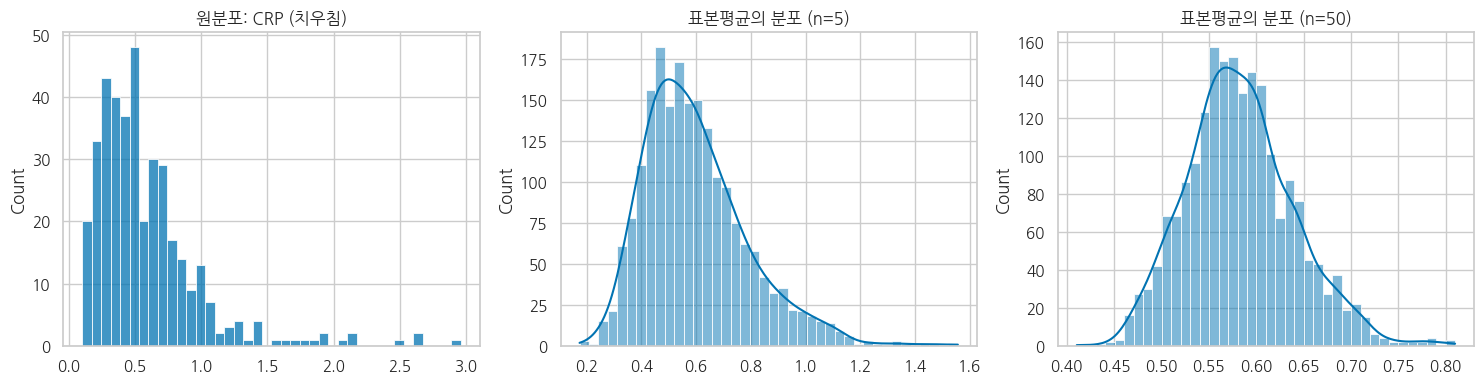

In [ ]:
pop = df['crp'].dropna().values     # 오른쪽으로 치우친 실제 분포

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(pop, bins=40, ax=ax[0]); ax[0].set_title('원분포: CRP (치우침)')

rng = np.random.default_rng(0)      # 난수생성기
for j, nn in enumerate([5, 50]):
    means = [rng.choice(pop, nn).mean() for _ in range(2000)]
    sns.histplot(means, kde=True, bins=40, ax=ax[j+1])
    ax[j+1].set_title(f'표본평균의 분포 (n={nn})')
plt.tight_layout(); plt.show()

In [ ]:
from scipy import stats

# 우리 데이터의 SBP를 '모집단'처럼 취급 (진짜 모평균을 우리가 안다고 가정)
pop = df['sbp'].dropna().values
mu_true = pop.mean()
print(f"[가정] 진짜 모평균 μ = {mu_true:.2f}  (현실에선 모르는 값)\n")

# (1) 표본 하나만 뽑았을 때: 내 평균은 모평균과 얼마나 다른가?
rng = np.random.default_rng(1)
n = 30
one_sample = rng.choice(pop, n, replace=False)
xbar = one_sample.mean()
print(f"내가 뽑은 표본(n={n}) 평균 = {xbar:.2f}")
print(f"진짜 μ와의 차이 = {xbar - mu_true:+.2f}")
print("→ 이 한 번으로는 '얼마나 믿을 만한지' 알 수 없다\n")

# (2) 만약 다시 뽑는다면? 표본평균의 '흔들림'을 직접 관찰
many_means = [rng.choice(pop, n).mean() for _ in range(5000)]
print(f"표본평균 5000개의 표준편차(실측 흔들림) = {np.std(many_means):.2f}")
print(f"이론 표준오차 SE = SD/√n = {pop.std(ddof=1)/np.sqrt(n):.2f}")
print("→ 둘이 거의 같다! '흔들림의 크기' = 표준오차(SE)\n")

# (3) 표본 하나만으로 신뢰구간 만들기
se = one_sample.std(ddof=1) / np.sqrt(n)        # 표본 하나로 SE 추정
ci_low  = xbar - 1.96 * se
ci_high = xbar + 1.96 * se
print(f"표본평균 = {xbar:.2f},  SE = {se:.2f}")
print(f"95% 신뢰구간 = ({ci_low:.2f}, {ci_high:.2f})")
print(f"진짜 μ={mu_true:.2f} 가 구간 안에 있나? "
      f"{'예' if ci_low <= mu_true <= ci_high else '아니오'}")

# (4) '95% 신뢰구간'이 정말 95%인지 검증
hit = 0
for _ in range(1000):
    s = rng.choice(pop, n)
    m, e = s.mean(), s.std(ddof=1)/np.sqrt(n)
    if m - 1.96*e <= mu_true <= m + 1.96*e:
        hit += 1
print(f"1000개 신뢰구간 중 μ를 포함한 비율 = {hit/1000*100:.1f}%")



[가정] 진짜 모평균 μ = 139.75  (현실에선 모르는 값)

내가 뽑은 표본(n=30) 평균 = 136.30
진짜 μ와의 차이 = -3.45
→ 이 한 번으로는 '얼마나 믿을 만한지' 알 수 없다

표본평균 5000개의 표준편차(실측 흔들림) = 2.19
이론 표준오차 SE = SD/√n = 2.22
→ 둘이 거의 같다! '흔들림의 크기' = 표준오차(SE)

표본평균 = 136.30,  SE = 2.05
95% 신뢰구간 = (132.27, 140.33)
진짜 μ=139.75 가 구간 안에 있나? 예
1000개 신뢰구간 중 μ를 포함한 비율 = 94.9%


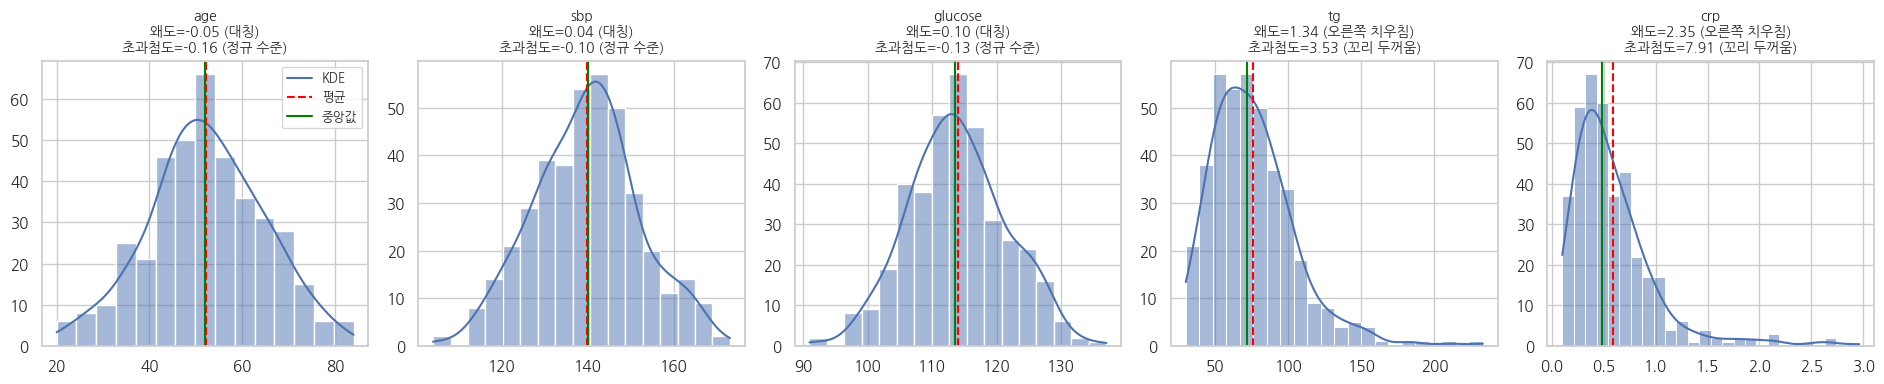

In [ ]:
cols = ['age', 'sbp', 'glucose', 'tg', 'crp']

# --- 시각화: 각 변수의 분포 + 평균·중앙값 위치로 치우침 확인 ---
fig, axes = plt.subplots(1, len(cols), figsize=(19, 4.0))
for ax, col in zip(axes, cols):
    s = df[col].dropna()
    sns.histplot(s, kde=True, ax=ax, color='#4C72B0')
    ax.axvline(s.mean(),   color='red',   ls='--', lw=1.5)   # 평균
    ax.axvline(s.median(), color='green', ls='-',  lw=1.5)   # 중앙값
    # 제목에 왜도·초과첨도 표시 (대칭/치우침 + 꼬리 두께)
    skew, kurt = s.skew(), s.kurt()
    shape = '대칭' if abs(skew) < 0.5 else '오른쪽 치우침' if skew > 0 else '왼쪽 치우침'
    tail  = '꼬리 두꺼움' if kurt > 0.5 else '꼬리 얇음' if kurt < -0.5 else '정규 수준'
    ax.set_title(f'{col}\n왜도={skew:.2f} ({shape})\n초과첨도={kurt:.2f} ({tail})',
                 fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
# 범례는 한 번만
axes[0].legend(['KDE', '평균', '중앙값'], fontsize=9)
plt.tight_layout(); plt.show()

원본    왜도=1.34
log     왜도=0.03
Box-Cox(λ=-0.02) 왜도=-0.00


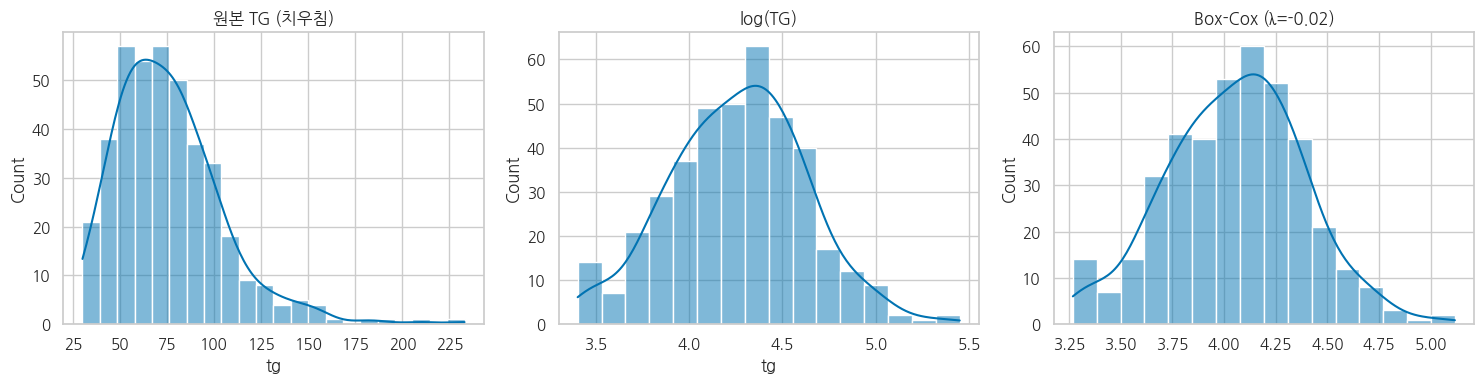

In [ ]:
tg = df['tg'].dropna()
print(f"원본    왜도={tg.skew():.2f}")

log_tg = np.log(tg)
bc, lam = stats.boxcox(tg)                  # λ 자동 추정
print(f"log     왜도={pd.Series(log_tg).skew():.2f}")
print(f"Box-Cox(λ={lam:.2f}) 왜도={pd.Series(bc).skew():.2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(tg, kde=True, ax=ax[0]);     ax[0].set_title('원본 TG (치우침)')
sns.histplot(log_tg, kde=True, ax=ax[1]); ax[1].set_title('log(TG)')
sns.histplot(bc, kde=True, ax=ax[2]);     ax[2].set_title(f'Box-Cox (λ={lam:.2f})')
plt.tight_layout(); plt.show()

평균 SBP = 139.75  (기준 130)
t = 16.053,  df = 399,  p = 0.0000
95% 신뢰구간 = (138.56, 140.95)
판정: 기준과 유의하게 다름
STD= 12.154
Cohen's d = 0.803


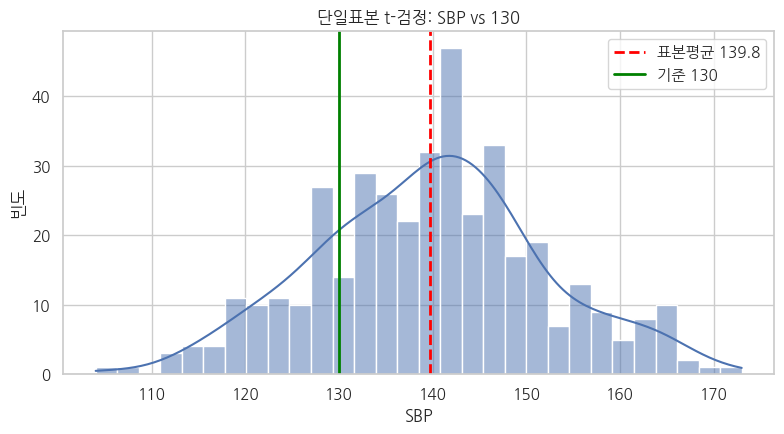

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

sbp = df['sbp'].dropna()
mu0 = 130   # 기준값(가설상의 참고치)

# --- 단일표본 t-검정 ---
t, p = stats.ttest_1samp(sbp, mu0)
n = len(sbp)
se = sbp.std(ddof=1) / np.sqrt(n)
ci = stats.t.interval(0.95, df=n-1, loc=sbp.mean(), scale=se)

print(f"평균 SBP = {sbp.mean():.2f}  (기준 {mu0})")
print(f"t = {t:.3f},  df = {n-1},  p = {p:.4f}")
print(f"95% 신뢰구간 = ({ci[0]:.2f}, {ci[1]:.2f})")
print("판정:", "기준과 유의하게 다름" if p < 0.05 else "유의한 차이 없음")

# --- 효과크기(Cohen's d, 단일표본) ---
d = (sbp.mean() - mu0) / sbp.std(ddof=1)
print(f"STD= {sbp.std(ddof=1):.3f}")
print(f"Cohen's d = {d:.3f}")

# --- 시각화 ---
plt.figure(figsize=(8, 4.5))
sns.histplot(sbp, bins=30, kde=True, color='#4C72B0')
plt.axvline(sbp.mean(), color='red', ls='--', lw=2, label=f'표본평균 {sbp.mean():.1f}')
plt.axvline(mu0, color='green', ls='-', lw=2, label=f'기준 {mu0}')
plt.title('단일표본 t-검정: SBP vs 130'); plt.xlabel('SBP'); plt.ylabel('빈도')
plt.legend(); plt.tight_layout(); plt.show()

남 n=211, 평균=140.73, SD=12.34
여 n=189, 평균=138.67, SD=11.88

[Levene] p = 0.5897 → 등분산 가정 OK
Student t = 1.699, p = 0.0901
Welch   t = 1.703, p = 0.0894
Cohen's d = 0.170


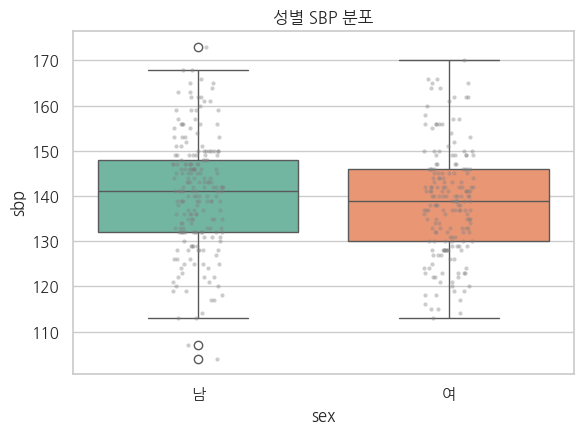

In [ ]:
from scipy import stats

g_m = df.loc[df['sex'] == '남', 'sbp'].dropna()
g_f = df.loc[df['sex'] == '여', 'sbp'].dropna()

print(f"남 n={len(g_m)}, 평균={g_m.mean():.2f}, SD={g_m.std(ddof=1):.2f}")
print(f"여 n={len(g_f)}, 평균={g_f.mean():.2f}, SD={g_f.std(ddof=1):.2f}")

# --- ① 등분산 점검: Levene ---
lev_stat, lev_p = stats.levene(g_m, g_f)
print(f"\n[Levene] p = {lev_p:.4f} → "
      f"{'등분산 가정 OK' if lev_p > 0.05 else '등분산 위배 → Welch 권장'}")

# --- ② Student's t (등분산 가정) vs Welch (등분산 비가정) ---
t1, p1 = stats.ttest_ind(g_m, g_f, equal_var=True)    # Student
t2, p2 = stats.ttest_ind(g_m, g_f, equal_var=False)   # Welch
print(f"Student t = {t1:.3f}, p = {p1:.4f}")
print(f"Welch   t = {t2:.3f}, p = {p2:.4f}")

# --- ③ 효과크기: Cohen's d (합동 SD) ---
n1, n2 = len(g_m), len(g_f)
sp = np.sqrt(((n1-1)*g_m.var(ddof=1) + (n2-1)*g_f.var(ddof=1)) / (n1+n2-2))
d = (g_m.mean() - g_f.mean()) / sp
print(f"Cohen's d = {d:.3f}")

# --- 시각화: 박스플롯 ---
plt.figure(figsize=(6, 4.5))
sns.boxplot(x='sex', y='sbp', data=df, hue='sex', palette='Set2', legend=False)
sns.stripplot(x='sex', y='sbp', data=df, color='gray', alpha=0.4, size=3)
plt.title('성별 SBP 분포'); plt.tight_layout(); plt.show()

전 평균=139.75, 후 평균=138.07
평균 감소 d̄=1.68
[대응 t] t=6.757, p=0.0000
[독립 t(잘못)] t=1.885, p=0.0598  ← 짝지음 무시로 검정력 손실
Cohen's d(paired) = 0.338


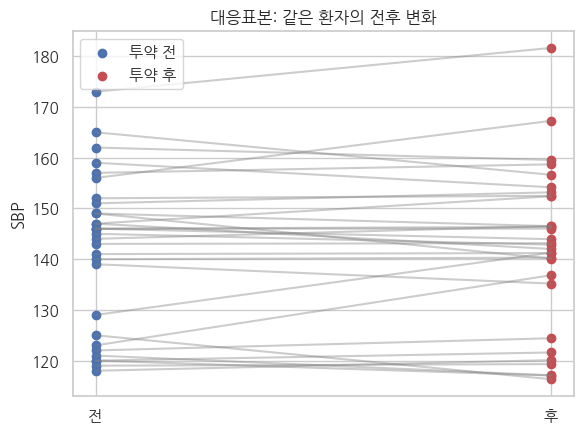

In [ ]:
from scipy import stats

# --- 전후 자료 시뮬레이션: 실제 SBP를 '투약 전'으로,
#     약효(평균 -1.5)+개인변동을 더해 '투약 후' 생성 ---
rng = np.random.default_rng(0)
before = df['sbp'].dropna().values
after  = before - 1.5 + rng.normal(0, 5, size=len(before))   # 평균 1.5 감소 가정

# --- 대응표본 t-검정 ---
t_p, p_p = stats.ttest_rel(before, after)
diff = before - after
print(f"전 평균={before.mean():.2f}, 후 평균={after.mean():.2f}")
print(f"평균 감소 d̄={diff.mean():.2f}")
print(f"[대응 t] t={t_p:.3f}, p={p_p:.4f}")

# --- 비교: 같은 자료를 독립표본으로 잘못 분석하면? ---
t_i, p_i = stats.ttest_ind(before, after)
print(f"[독립 t(잘못)] t={t_i:.3f}, p={p_i:.4f}  ← 짝지음 무시로 검정력 손실")

# --- 효과크기: 대응 Cohen's d (차이의 SD 기준) ---
d_paired = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d(paired) = {d_paired:.3f}")

# --- 시각화: 전후 연결선(일부 표본만) ---
plt.figure(figsize=(6, 4.5))
idx = rng.choice(len(before), 30, replace=False)
for i in idx:
    plt.plot([0, 1], [before[i], after[i]], color='gray', alpha=0.4)
plt.scatter([0]*30, before[idx], color='#4C72B0', label='투약 전')
plt.scatter([1]*30, after[idx], color='#C44E52', label='투약 후')
plt.xticks([0, 1], ['전', '후']); plt.ylabel('SBP')
plt.title('대응표본: 같은 환자의 전후 변화'); plt.legend()
plt.tight_layout(); plt.show()

[Shapiro] 흡연: W=0.737, p=0.0000 → 정규 위배
[Shapiro] 비흡연: W=0.805, p=0.0000 → 정규 위배
[Levene] p=0.7549

[Mann-Whitney U] U=17296.5, p=0.0013 (중앙값 비교, 순위 기반)
흡연 중앙값=0.60, 비흡연 중앙값=0.46
[참고: Welch t] t=2.021, p=0.0449


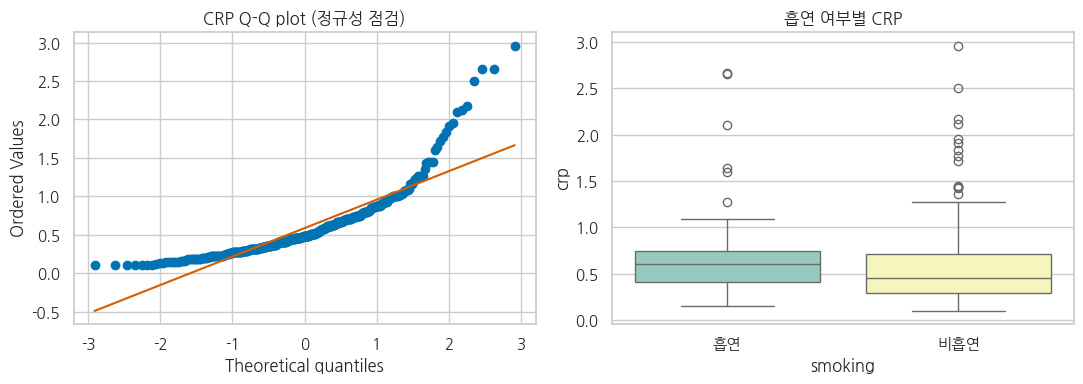

In [ ]:
from scipy import stats

a = df.loc[df['smoking'] == '흡연',  'crp'].dropna()
b = df.loc[df['smoking'] == '비흡연', 'crp'].dropna()

# --- ① 정규성: Shapiro-Wilk ---
for name, g in [('흡연', a), ('비흡연', b)]:
    w, pw = stats.shapiro(g)
    print(f"[Shapiro] {name}: W={w:.3f}, p={pw:.4f} → "
          f"{'정규 가정 OK' if pw > 0.05 else '정규 위배'}")

# --- ② 등분산: Levene ---
lev, plev = stats.levene(a, b)
print(f"[Levene] p={plev:.4f}")

# --- ③ 가정 위배 시: 비모수 Mann-Whitney U ---
u, pu = stats.mannwhitneyu(a, b, alternative='two-sided')
print(f"\n[Mann-Whitney U] U={u:.1f}, p={pu:.4f} (중앙값 비교, 순위 기반)")
print(f"흡연 중앙값={a.median():.2f}, 비흡연 중앙값={b.median():.2f}")

# --- 참고: 그냥 t를 쓰면? (가정 위배 상태) ---
tt, pt = stats.ttest_ind(a, b, equal_var=False)
print(f"[참고: Welch t] t={tt:.3f}, p={pt:.4f}")

# --- 시각화: Q-Q plot + 박스플롯 ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(df['crp'].dropna(), dist='norm', plot=ax[0])
ax[0].set_title('CRP Q-Q plot (정규성 점검)')
sns.boxplot(x='smoking', y='crp', data=df,hue='smoking', palette='Set3', legend=False, ax=ax[1])
ax[1].set_title('흡연 여부별 CRP')
plt.tight_layout(); plt.show()

수도권: n=158, 평균=113.6, SD=7.1
영남: n=115, 평균=114.0, SD=7.9
충청: n=51, 평균=114.0, SD=7.5
호남: n=76, 평균=114.7, SD=7.9

[Levene] p=0.1042
[ANOVA] F=0.396, p=0.7560 → 차이 없음
η² = 0.003 (결과 변동 중 region이 설명하는 비율)


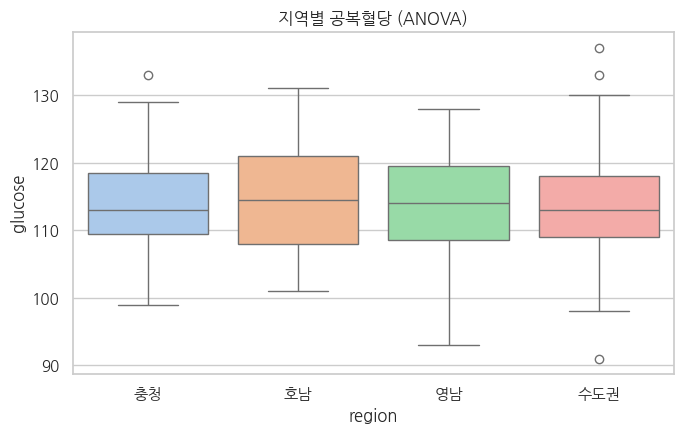

In [ ]:
from scipy import stats

groups = [g['glucose'].dropna().values for _, g in df.groupby('region')]
labels = df['region'].dropna().unique()

# 집단별 요약
for name, g in df.groupby('region'):
    s = g['glucose'].dropna()
    print(f"{name}: n={len(s)}, 평균={s.mean():.1f}, SD={s.std(ddof=1):.1f}")

# --- ① 등분산: Levene ---
lev, plev = stats.levene(*groups)
print(f"\n[Levene] p={plev:.4f}")

# --- ② 일원배치 ANOVA ---
F, p = stats.f_oneway(*groups)
print(f"[ANOVA] F={F:.3f}, p={p:.4f} → "
      f"{'집단 간 차이 있음' if p < 0.05 else '차이 없음'}")

# --- ③ 효과크기: eta-squared = SS_between / SS_total ---
grand = df['glucose'].dropna().mean()
ss_between = sum(len(g)*(g.mean()-grand)**2 for g in groups)
ss_total = sum(((df['glucose'].dropna()-grand)**2))
eta2 = ss_between / ss_total
print(f"η² = {eta2:.3f} (결과 변동 중 region이 설명하는 비율)")

# --- 시각화 ---
plt.figure(figsize=(7, 4.5))
sns.boxplot(x='region', y='glucose', data=df, hue='region', palette='pastel', legend=False)
plt.title('지역별 공복혈당 (ANOVA)'); plt.tight_layout(); plt.show()

운동 0회: n= 63, 평균=46.1, SD=7.9
운동 1회: n= 91, 평균=48.3, SD=7.3
운동 2회: n= 87, 평균=50.8, SD=8.4
운동 3회: n= 61, 평균=51.9, SD=7.2
운동 4회: n= 48, 평균=54.4, SD=6.8
운동 5회: n= 44, 평균=54.4, SD=9.0

[Levene] p=0.3036
[ANOVA] F=10.470, p=1.93e-09 → 집단 간 차이 있음
η² = 0.119 (HDL 변동 중 운동횟수가 설명하는 비율)


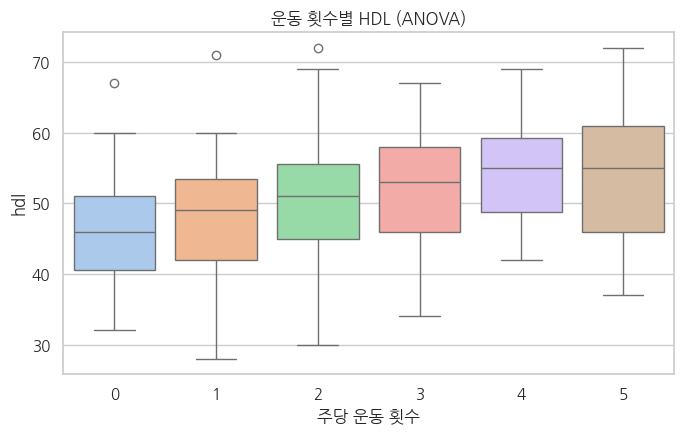

In [ ]:
from scipy import stats

# exercise_freq(운동 횟수)를 집단으로 보고 hdl 평균 비교
sub = df[['exercise_freq', 'hdl']].dropna()
groups = [g['hdl'].values for _, g in sub.groupby('exercise_freq')]

# 집단별 요약
for k, g in sub.groupby('exercise_freq'):
    s = g['hdl']
    print(f"운동 {k}회: n={len(s):3d}, 평균={s.mean():.1f}, SD={s.std(ddof=1):.1f}")

# --- ① 등분산: Levene ---
lev, plev = stats.levene(*groups)
print(f"\n[Levene] p={plev:.4f}")

# --- ② 일원배치 ANOVA ---
F, p = stats.f_oneway(*groups)
print(f"[ANOVA] F={F:.3f}, p={p:.2e} → "
      f"{'집단 간 차이 있음' if p < 0.05 else '차이 없음'}")

# --- ③ 효과크기: eta-squared ---
grand = sub['hdl'].mean()
ss_between = sum(len(g)*(g.mean()-grand)**2 for g in groups)
ss_total = ((sub['hdl']-grand)**2).sum()
print(f"η² = {ss_between/ss_total:.3f} (HDL 변동 중 운동횟수가 설명하는 비율)")

# --- 시각화 ---
plt.figure(figsize=(7, 4.5))
sns.boxplot(x='exercise_freq', y='hdl', data=df,
            hue='exercise_freq', palette='pastel', legend=False)
plt.title('운동 횟수별 HDL (ANOVA)'); plt.xlabel('주당 운동 횟수')
plt.tight_layout(); plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats

sub = df[['exercise_freq', 'hdl']].dropna()
sub['g'] = sub['exercise_freq'].astype(str)   # 집단 라벨을 문자열로

# --- Tukey HSD: 모든 쌍 비교 (보정 포함) ---
tukey = pairwise_tukeyhsd(endog=sub['hdl'], groups=sub['g'], alpha=0.05)
print(tukey)            # reject=True인 쌍이 유의하게 다른 조합



Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   2.1538 0.5399 -1.4984  5.8061  False
     0      2   4.6158 0.0051  0.9293  8.3022   True
     0      3   5.7424 0.0007  1.7395  9.7452   True
     0      4   8.2738    0.0  4.0044 12.5432   True
     0      5   8.2662    0.0  3.8881 12.6444   True
     1      2   2.4619 0.2841 -0.8794  5.8033  False
     1      3   3.5885 0.0616 -0.0989   7.276  False
     1      4     6.12 0.0002  2.1448 10.0952   True
     1      5   6.1124 0.0003  2.0206 10.2042   True
     2      3   1.1266 0.9541 -2.5947   4.848  False
     2      4    3.658 0.0961 -0.3486  7.6647  False
     2      5   3.6505 0.1163 -0.4719  7.7728  False
     3      4   2.5314 0.5417 -1.7681   6.831  False
     3      5   2.5238 0.5725 -1.8837  6.9314  False
     4      5  -0.0076    1.0 -4.6585  4.6434  False
----------------------------------------------

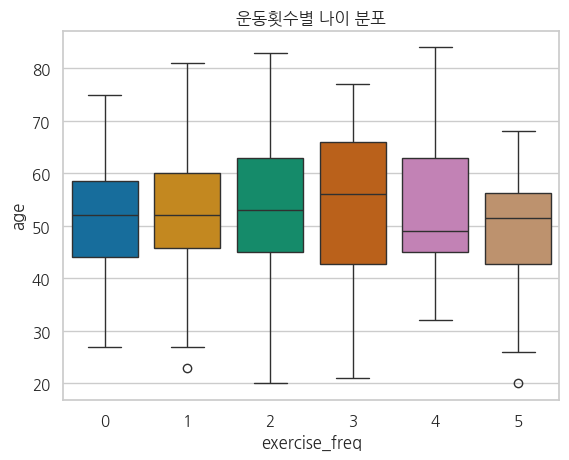

운동 0회: Shapiro p = 0.743
운동 1회: Shapiro p = 0.458
운동 2회: Shapiro p = 0.449
운동 3회: Shapiro p = 0.074
운동 4회: Shapiro p = 0.023
운동 5회: Shapiro p = 0.152
Kruskal-Wallis H = 3.88,  p = 0.5674


In [ ]:
# (1) 그룹별 분포 확인 — 박스플롯
sns.boxplot(data=df, x='exercise_freq', y='age',
            hue='exercise_freq', palette='colorblind', legend=False)
plt.title('운동횟수별 나이 분포'); plt.show()

df.groupby('exercise_freq')['age'].median()

# (2) 정규성 점검 — 비모수를 선택하는 근거
for k, g in df.groupby('exercise_freq'):
    print(f'운동 {k}회: Shapiro p = {stats.shapiro(g["age"]).pvalue:.3f}')

# (3) Kruskal-Wallis — 그룹 간 전체 차이 검정
groups = [g['age'].values for _, g in df.groupby('exercise_freq')]
H, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis H = {H:.2f},  p = {p:.4g}')


metabolic_syndrome    0   1
smoking                    
비흡연                 229  70
흡연                   54  47
metabolic_syndrome     0     1
smoking                       
비흡연                 76.6  23.4
흡연                  53.5  46.5
χ²=18.405, df=1, p=0.0000
기대빈도:
 metabolic_syndrome      0     1
smoking                        
비흡연                 211.5  87.5
흡연                   71.5  29.5
φ = 0.215


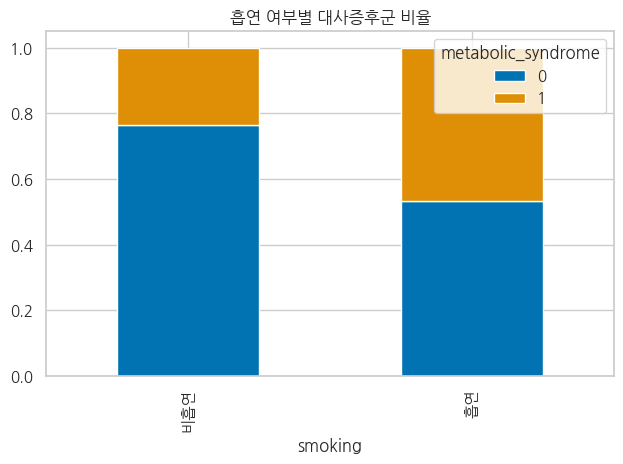

In [ ]:
from scipy import stats
import pandas as pd

# --- 교차표 (관측빈도) ---
tab = pd.crosstab(df['smoking'], df['metabolic_syndrome'])
print(tab)

# 비율로도 확인
print((tab.div(tab.sum(axis=1), axis=0) * 100).round(1))   # 행 기준 %

# --- 카이제곱 독립성 검정 ---
chi2, p, dof, expected = stats.chi2_contingency(tab)
print(f"χ²={chi2:.3f}, df={dof}, p={p:.4f}")
print("기대빈도:\n", pd.DataFrame(expected,
      index=tab.index, columns=tab.columns).round(1))   # ≥5 점검

# --- 효과크기: φ (2×2) ---
n = tab.values.sum()
phi = (chi2 / n) ** 0.5
print(f"φ = {phi:.3f}")

# --- 시각화: 비율 막대 ---
import matplotlib.pyplot as plt
(tab.div(tab.sum(axis=1), axis=0)).plot(kind='bar', stacked=True)
plt.title('흡연 여부별 대사증후군 비율'); plt.tight_layout(); plt.show()

In [ ]:
from scipy import stats
import pandas as pd

# 일부 지역만 추려 표본을 작게 만든 상황 가정 (희귀 사건 모사)
sub = df[df['region'].isin(['충청', '호남'])]
tab = pd.crosstab(sub['region'], sub['metabolic_syndrome'])
print(tab)

# --- 기대빈도 점검 ---
chi2, p, dof, expected = stats.chi2_contingency(tab)
exp = pd.DataFrame(expected, index=tab.index, columns=tab.columns)
print("기대빈도:\n", exp.round(1))
small = (exp < 5).sum().sum()
print(f"기대빈도 <5 셀 개수: {small}  → {'Fisher 권장' if small>0 else 'χ² 가능'}")

# --- Fisher 정확검정 (2×2) ---
odds, p_fisher = stats.fisher_exact(tab)
print(f"[Fisher] OR={odds:.2f}, p={p_fisher:.4f}")
print(f"[참고: χ²] p={p:.4f}")   # 근사와 정확값 비교

metabolic_syndrome   0   1
region                    
충청                  40  11
호남                  51  25
기대빈도:
 metabolic_syndrome     0     1
region                        
충청                  36.5  14.5
호남                  54.5  21.5
기대빈도 <5 셀 개수: 0  → χ² 가능
[Fisher] OR=1.78, p=0.2281
[참고: χ²] p=0.2350


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats

# --- 두 검정이 정반대 결론을 내는 표 직접 만들기 ---
demo = pd.DataFrame([[5, 5], [25, 5]],
                    index=['전:양성', '전:음성'],
                    columns=['후:양성', '후:음성'])
print(demo)

res = mcnemar(demo.values, exact=False, correction=True)
chi2_2, p2, _, _ = stats.chi2_contingency(demo)

print(f"[McNemar] p={res.pvalue:.4f}  → {'유의함' if res.pvalue < 0.05 else '유의하지 않음'}")
print(f"[χ² (잘못)] p={p2:.4f}  → {'유의함' if p2 < 0.05 else '유의하지 않음'}")

      후:양성  후:음성
전:양성     5     5
전:음성    25     5
[McNemar] p=0.0005  → 유의함
[χ² (잘못)] p=0.0917  → 유의하지 않음


Pearson  r = 0.308,  p = 2.89e-10
Spearman ρ = 0.311,  p = 2.13e-10


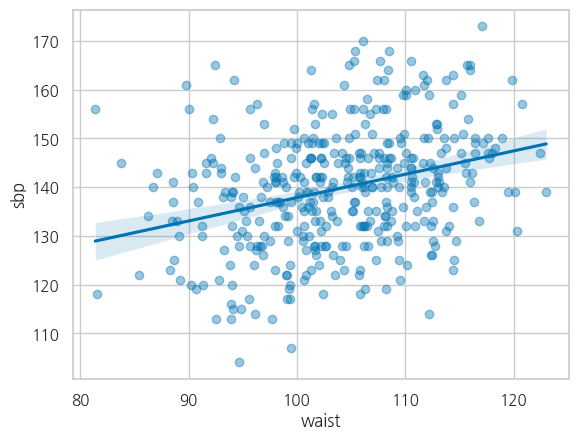

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

sub = df[['waist','sbp']].dropna()

# 산점도 + 회귀선
sns.regplot(x='waist', y='sbp', data=sub,
            scatter_kws={'alpha':0.4})

# Pearson(직선) vs Spearman(순위)
r,  p  = stats.pearsonr(sub['waist'], sub['sbp'])
rs, ps = stats.spearmanr(sub['waist'], sub['sbp'])
print(f'Pearson  r = {r:.3f},  p = {p:.2e}')
print(f'Spearman ρ = {rs:.3f},  p = {ps:.2e}')

Text(0.5, 1.0, '연속형 변수 상관행렬')

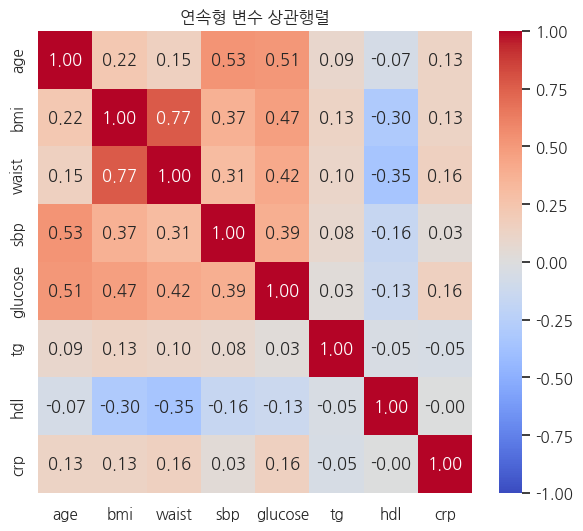

In [ ]:
cont = df[['age','bmi','waist','sbp',
           'glucose','tg','hdl','crp']].dropna()

corr = cont.corr(method='pearson')   # 기본 Pearson
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('연속형 변수 상관행렬')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    112.8056      2.242     50.306      0.000     108.397     117.214
age            0.5155      0.042     12.351      0.000       0.433       0.598
R-squared = 0.277


<Axes: xlabel='age', ylabel='sbp'>

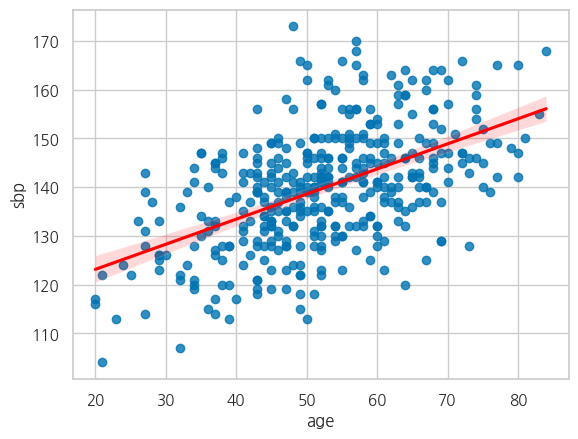

In [ ]:
import statsmodels.formula.api as smf

m1 = smf.ols('sbp ~ age', data=df).fit()
print(m1.summary().tables[1])      # 계수표
print('R-squared =', round(m1.rsquared, 3))

# 회귀선 시각화
sns.regplot(x='age', y='sbp', data=df,
            line_kws={'color':'red'})

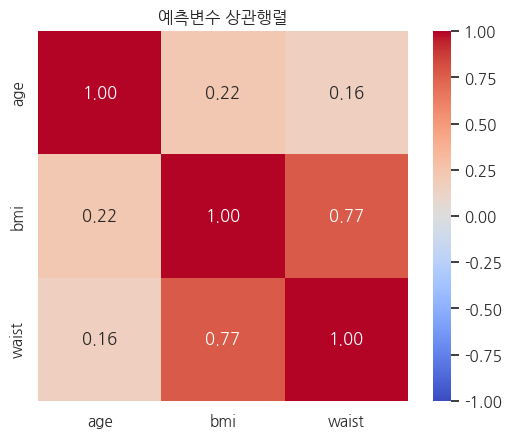

공선성 후보쌍(|r|>=0.7): [('bmi', 'waist', np.float64(0.77))]
[A] VIF : {'age': np.float64(1.05), 'bmi': np.float64(2.53), 'waist': np.float64(2.46)}
    bmi계수=0.970  adjR²=0.341
[B] VIF : {'age': np.float64(1.05), 'bmi': np.float64(1.05)}
    bmi계수=1.113  adjR²=0.342


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# ── STEP 1. 예측변수 상관 히트맵 (공선성 후보 탐색) ──
preds = ['age', 'bmi', 'waist']
corr = df[preds].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('예측변수 상관행렬'); plt.show()

# 임계값 이상 쌍 자동 추출 (|r| >= 0.7)
high = [(a, b, round(corr.loc[a, b], 2))
        for i, a in enumerate(preds) for b in preds[i+1:]
        if abs(corr.loc[a, b]) >= 0.7]
print('공선성 후보쌍(|r|>=0.7):', high)

# ── STEP 2. VIF 계산 함수 ──
def vif_table(cols):
    X = sm.add_constant(df[cols].dropna())
    return {c: round(variance_inflation_factor(X.values, i), 2)
            for i, c in enumerate(X.columns) if c != 'const'}

# ── STEP 3. 두 모형 비교 (waist 포함 A vs 제외 B) ──
mA = smf.ols('sbp ~ age + bmi + waist + C(sex)', data=df).fit()
mB = smf.ols('sbp ~ age + bmi + C(sex)',        data=df).fit()

print('[A] VIF :', vif_table(['age','bmi','waist']))
print('    bmi계수=%.3f  adjR²=%.3f' % (mA.params['bmi'], mA.rsquared_adj))
print('[B] VIF :', vif_table(['age','bmi']))
print('    bmi계수=%.3f  adjR²=%.3f' % (mB.params['bmi'], mB.rsquared_adj))

In [ ]:

d = df.dropna(subset=['age','bmi','smoking',
                      'metabolic_syndrome'])

# 단변량(crude)
mu = smf.logit('metabolic_syndrome ~ bmi',
               data=d).fit(disp=0)
# 다변량(보정)
m  = smf.logit('metabolic_syndrome ~ age + bmi'
               ' + C(smoking)', data=d).fit(disp=0)

print('crude   OR(bmi) =', round(np.exp(mu.params['bmi']),3))
print('adjusted OR(bmi) =', round(np.exp(m.params['bmi']),3))

# OR과 CI를 함께 출력
def show(name, res, var='bmi'):
    OR = np.exp(res.params[var])
    ci = np.exp(res.conf_int().loc[var])   # 계수 CI를 지수변환 -> OR의 CI
    print(f"{name} OR(bmi) = {OR:.3f}  [95% CI: {ci[0]:.3f} ~ {ci[1]:.3f}]")

show('crude   ', mu)
show('adjusted', m)

crude   OR(bmi) = 1.218
adjusted OR(bmi) = 1.21
crude    OR(bmi) = 1.218  [95% CI: 1.121 ~ 1.322]
adjusted OR(bmi) = 1.210  [95% CI: 1.110 ~ 1.318]


                     OR    low   high
Intercept         0.002  0.000  0.014
C(smoking)[T.흡연]  2.907  1.775  4.761
age               1.016  0.997  1.036
bmi               1.210  1.110  1.318


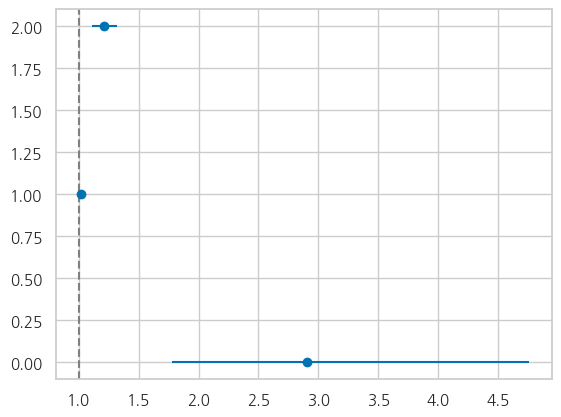

In [ ]:
m = smf.logit('metabolic_syndrome ~ age + bmi'
              ' + C(smoking)', data=d).fit(disp=0)

OR = np.exp(m.params)
CI = np.exp(m.conf_int())
res = pd.DataFrame({'OR':OR, 'low':CI[0], 'high':CI[1]})
print(res.round(3))

# forest plot
plt.errorbar(res['OR'][1:], range(len(res)-1),
             xerr=[res['OR'][1:]-res['low'][1:],
                   res['high'][1:]-res['OR'][1:]],
             fmt='o'); plt.axvline(1, ls='--', color='gray')

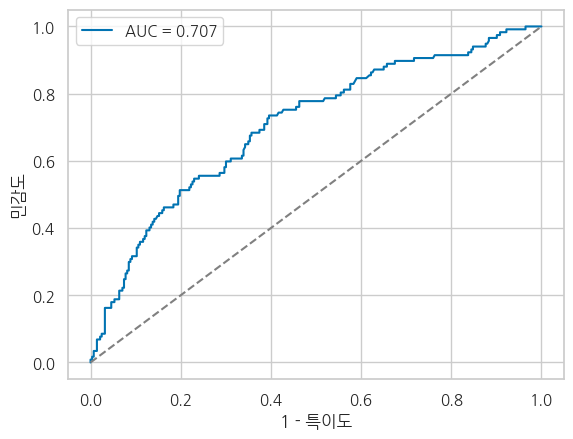

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

pred = m.predict(d)
auc  = roc_auc_score(d['metabolic_syndrome'], pred)
fpr, tpr, _ = roc_curve(d['metabolic_syndrome'], pred)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')  # 무작위 기준
plt.xlabel('1 - 특이도'); plt.ylabel('민감도')
plt.legend()